<a href="https://colab.research.google.com/github/sauraviitj/HopeLens/blob/main/scripts/01_Dataset_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np

In [ ]:
BASE_PATH = "/content/drive/MyDrive/HopeLens"

METADATA_PATH = os.path.join(BASE_PATH, "Data", "metadata", "song_semantic.csv")

LYRICS_PATH = os.path.join(BASE_PATH, "Data", "Lyrics")

In [ ]:
songs = pd.read_csv(METADATA_PATH)

songs.head()

,#,Song,filename,Category,Artist,semantic_category,Your Score,Nibedita Score,Tula Score,Human Mean,AI Score
0,1,Fix You,fix_you.txt,Healing,Coldplay,Very High,NaN,NaN,NaN,NaN,NaN
1,2,Up&Up,Up&up.txt,Perseverance,Coldplay,Very High,NaN,NaN,NaN,NaN,NaN
2,3,Paradise,paradise.txt,Hope & Escape,Coldplay,High,NaN,NaN,NaN,NaN,NaN
3,4,The Scientist,thescientist.txt,Regret & Reflection,Coldplay,Medium–High,NaN,NaN,NaN,NaN,NaN
4,5,Everglow,everglow.txt,Love & Loss,Coldplay,Medium–High,NaN,NaN,NaN,NaN,NaN


In [ ]:
import os

missing_files = []

for file in songs["filename"]:

    file_path = os.path.join(LYRICS_PATH, file)

    if not os.path.exists(file_path):
        missing_files.append(file)

if len(missing_files) == 0:
    print("✅ All lyric files found!")
else:
    print("❌ Missing files:")
    for f in missing_files:
        print(f)

✅ All lyric files found!


In [ ]:
lyrics_dataset = {}

for _, row in songs.iterrows():

    filename = row["filename"]

    file_path = os.path.join(LYRICS_PATH, filename)

    with open(file_path, "r", encoding="utf-8") as f:

        lyrics = [line.strip() for line in f.readlines() if line.strip()]

    lyrics_dataset[row["Song"]] = {
        "artist": row["Artist"],
        "filename": filename,
        "lyrics": lyrics
    }

print(f"Loaded {len(lyrics_dataset)} songs.")

Loaded 25 songs.


In [ ]:
song = "Fix You"

print("Artist:", lyrics_dataset[song]["artist"])
print()

for line in lyrics_dataset[song]["lyrics"][:10]:
    print(line)

Artist: Coldplay

When you try your best, but you don't succeed
When you get what you want, but not what you need
When you feel so tired, but you can't sleep
Stuck in reverse
And the tears come streaming down your face
When you lose something you can't replace
When you love someone, but it goes to waste
Could it be worse?
Lights will guide you home
And ignite your bones


In [ ]:
total_lines = 0
total_words = 0
vocabulary = set()

for song in lyrics_dataset.values():

    total_lines += len(song["lyrics"])

    for line in song["lyrics"]:

        words = line.split()

        total_words += len(words)

        vocabulary.update(
            [w.lower().strip(".,!?;:'\"()") for w in words]
        )

print(f"Number of Songs      : {len(lyrics_dataset)}")
print(f"Total Lines          : {total_lines}")
print(f"Total Words          : {total_words}")
print(f"Vocabulary Size      : {len(vocabulary)}")
print(f"Average Lines/Song   : {total_lines/len(lyrics_dataset):.2f}")
print(f"Average Words/Song   : {total_words/len(lyrics_dataset):.2f}")

Number of Songs      : 25
Total Lines          : 854
Total Words          : 5386
Vocabulary Size      : 914
Average Lines/Song   : 34.16
Average Words/Song   : 215.44


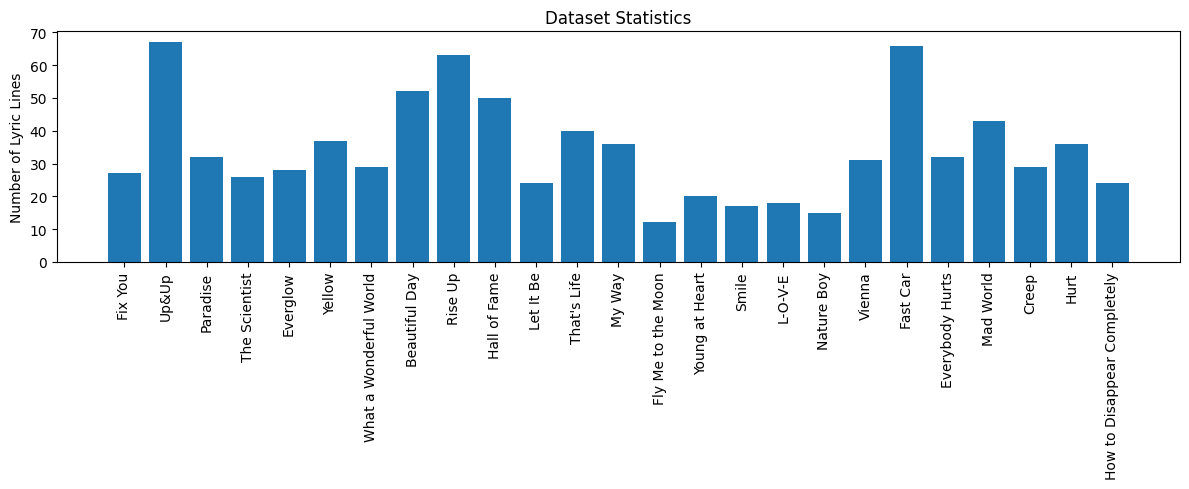

In [ ]:
import matplotlib.pyplot as plt

line_counts = []

song_names = []

for song_name, song in lyrics_dataset.items():

    song_names.append(song_name)

    line_counts.append(len(song["lyrics"]))

plt.figure(figsize=(12,5))

plt.bar(song_names, line_counts)

plt.xticks(rotation=90)

plt.ylabel("Number of Lyric Lines")

plt.title("Dataset Statistics")

plt.tight_layout()

plt.show()